# Objective 5 — Career Path Recommendation

Loads user profile from Objective 3, builds data-driven career tracks from the JobStreet dataset, scores the user against each track using the same skill keywords from Objective 3, and produces a career roadmap with progression path and alternatives.

## Install Packages

In [4]:
# Run once
!pip -q install pandas numpy scikit-learn matplotlib seaborn python-dateutil

## Import Libraries

In [6]:
import os, re, ast, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## Step 1: Load Outputs from Objectives 3 and 4

In [8]:
def parse_list(val):
    if isinstance(val, list): return val
    try: return ast.literal_eval(str(val))
    except: return []

# Skill gap results from Objective 3
gap_df = pd.read_csv('data/skill_gap_results.csv')
gap_df['missing_skills']  = gap_df['missing_skills'].apply(parse_list)
gap_df['matched_skills']  = gap_df['matched_skills'].apply(parse_list)
gap_df['required_skills'] = gap_df['required_skills'].apply(parse_list)

# Course recommendations from Objective 4
job_recs_df = pd.read_csv('data/job_course_recommendations.csv')

# User profile from Objective 3
with open('data/user_profile.json') as f:
    user_profile = json.load(f)

resume_skills     = user_profile['skills']
resume_education  = user_profile['education']
years_exp         = user_profile['years_experience']
resume_skills_set = set(s.lower() for s in resume_skills)

print(f'Skills ({len(resume_skills)}): {resume_skills}')
print(f'Experience : {years_exp} years')
print(f'Education  : {resume_education}')

Skills (10): ['Python', 'Java', 'C++', 'HTML', 'CSS', 'SQL', 'MYSQL', 'IBM DB2', 'Microsoft Excel', 'Microsoft Office Suite']
Experience : 4.3 years
Education  : ['Bachelor of Computer Science (Undergraduate) Aug 2023 - Aug 2026', 'Foundation in Information Technology Aug 2022 - Aug 2023']


## Step 2: Define Skill Keywords
Same list used in Objective 3 — ensures consistent comparison across all objectives.

In [10]:
# Same SKILL_KEYWORDS as Objective 3 
SKILL_KEYWORDS = [
    'python','java','javascript','typescript','c++','c#','c','r','php','ruby',
    'go','swift','kotlin','scala','matlab','perl','bash','shell','vba',
    'html','css','react','angular','vue','jquery','bootstrap','node.js',
    'django','flask','fastapi','spring','express','.net','laravel',
    'machine learning','deep learning','nlp','natural language processing',
    'computer vision','data science','data analysis','data mining','statistics',
    'statistical analysis','feature engineering','etl',
    'pandas','numpy','scikit-learn','tensorflow','pytorch','keras','xgboost',
    'matplotlib','seaborn','plotly','opencv',
    'sql','mysql','postgresql','mongodb','redis','oracle','sqlite',
    'elasticsearch','nosql','ms sql','dynamodb',
    'aws','azure','gcp','docker','kubernetes','terraform','ansible',
    'jenkins','git','ci/cd','linux','unix','airflow','kafka','spark',
    'hadoop','databricks','snowflake',
    'tableau','power bi','excel','sas','spss','google analytics',
    'microsoft office','powerpoint',
    'agile','scrum','jira','project management','devops','uml',
    'accounting','bookkeeping','auditing','taxation','financial reporting',
    'financial analysis','budgeting','forecasting','sap','quickbooks','xero',
    'digital marketing','seo','sem','social media','content marketing',
    'email marketing','google ads','crm','salesforce','market research',
    'recruitment','payroll','hris','training','performance management',
    'autocad','solidworks','electrical engineering','mechanical engineering',
    'civil engineering','quality control','iso',
    'patient care','clinical','nursing','pharmacy','laboratory',
    'communication','presentation','leadership','teamwork','negotiation',
    'customer service','problem solving','time management'
]

print(f'Total skill keywords: {len(SKILL_KEYWORDS)}')

Total skill keywords: 146


## Step 3: Load JobStreet Dataset and Discover Career Tracks

In [12]:
JOBS_CSV = 'data/jobstreet_all_job_dataset.csv'
jobs_df  = pd.read_csv(JOBS_CSV)

def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    return None

JOB_TITLE_COL = detect_col(jobs_df, ['job_title','Job Title','title','position'])
JOB_DESC_COL  = detect_col(jobs_df, ['job_description','descriptions','description','desc','requirements'])
JOB_CAT_COL   = detect_col(jobs_df, ['category','Category','field','industry','job_category','specialization'])

# Basic clean
jobs_df = jobs_df.dropna(subset=[c for c in [JOB_TITLE_COL, JOB_DESC_COL] if c])
for col in [JOB_TITLE_COL, JOB_DESC_COL]:
    if col: jobs_df[col] = jobs_df[col].astype(str).str.strip()
jobs_df = jobs_df[jobs_df[JOB_DESC_COL].str.len() >= 50].reset_index(drop=True)

# Remove non-English descriptions
def is_english(text, threshold=0.70):
    if not text.strip(): return False
    return sum(1 for c in text if ord(c) < 128) / len(text) >= threshold

jobs_df = jobs_df[jobs_df[JOB_DESC_COL].apply(is_english)].reset_index(drop=True)

print(f'Jobs loaded: {len(jobs_df):,}')

# Get career categories with at least 20 jobs
if JOB_CAT_COL and JOB_CAT_COL in jobs_df.columns:
    cat_counts = jobs_df[JOB_CAT_COL].value_counts()
    valid_cats = cat_counts[cat_counts >= 20].index.tolist()
    print(f'\nCareer categories ({len(valid_cats)}):')
    for cat in valid_cats[:20]:
        print(f'  {cat}: {cat_counts[cat]:,} jobs')
else:
    valid_cats = []
    print('No category column found.')

Jobs loaded: 68,790

Career categories (29):
  Accounting: 11,278 jobs
  Engineering: 8,967 jobs
  Information & Communication Technology: 8,663 jobs
  Administration & Office Support: 7,059 jobs
  Sales: 5,688 jobs
  Manufacturing, Transport & Logistics: 5,377 jobs
  Human Resources & Recruitment: 4,045 jobs
  Marketing & Communications: 2,998 jobs
  Banking & Financial Services: 2,635 jobs
  Call Centre & Customer Service: 1,775 jobs
  Construction: 1,616 jobs
  Retail & Consumer Products: 1,494 jobs
  Hospitality & Tourism: 969 jobs
  Healthcare & Medical: 910 jobs
  Design & Architecture: 877 jobs
  Education & Training: 795 jobs
  Real Estate & Property: 690 jobs
  Trades & Services: 598 jobs
  Science & Technology: 548 jobs
  Advertising, Arts & Media: 415 jobs


## Step 4: Tag Jobs by Seniority Tier

Tier distribution in dataset:
seniority_tier
Mid-Level       42413
Manager/Lead    10329
Junior           9257
Senior           6791
Name: count, dtype: int64


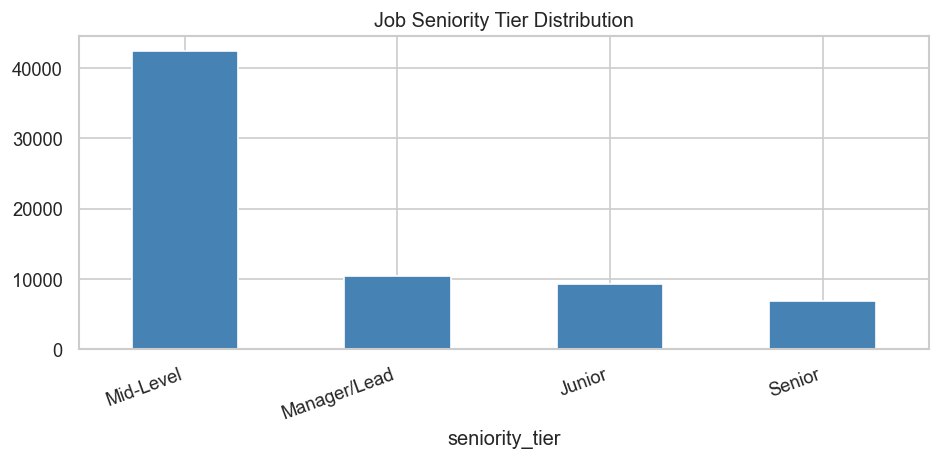

In [14]:
SENIORITY_MAP = {
    'Junior':       ['junior','entry','graduate','trainee','intern','fresh','associate','assistant'],
    'Mid-Level':    ['mid','intermediate','experienced','specialist','executive'],
    'Senior':       ['senior','sr.','sr ','lead','principal','expert','advanced'],
    'Manager/Lead': ['manager','head','director','chief','vp','vice president']
}
TIER_ORDER = ['Junior', 'Mid-Level', 'Senior', 'Manager/Lead']

def get_seniority(title):
    t = title.lower()
    for tier in reversed(TIER_ORDER):
        if any(kw in t for kw in SENIORITY_MAP[tier]):
            return tier
    return 'Mid-Level'

jobs_df['seniority_tier'] = jobs_df[JOB_TITLE_COL].apply(get_seniority)

tier_dist = jobs_df['seniority_tier'].value_counts()
print('Tier distribution in dataset:')
print(tier_dist)

tier_dist.plot(kind='bar', color='steelblue', figsize=(8,4),
               title='Job Seniority Tier Distribution')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Step 5: Extract Required Skills Per Tier Per Career Track
Uses the same SKILL_KEYWORDS from Objective 3 — counts how often each skill appears in job descriptions per tier. This gives a real, data-driven skill requirement profile for each career track and tier.

In [16]:
def extract_skills_for_tier(text_series, skill_keywords, min_jobs=3):
    """
    Count how many jobs in this tier mention each skill keyword.
    Returns skills that appear in at least min_jobs job descriptions.
    Same keyword matching as Objective 3 — whole-word regex.
    """
    texts = text_series.fillna('').astype(str).str.lower().tolist()
    if len(texts) < 3:
        return []
    combined = ' \n '.join(texts)
    skill_counts = {}
    for sk in skill_keywords:
        count = len(re.findall(r'\b' + re.escape(sk) + r'\b', combined))
        if count >= min_jobs:
            skill_counts[sk] = count
    # Return skills sorted by frequency — most demanded first
    return [sk for sk, _ in sorted(skill_counts.items(), key=lambda x: -x[1])[:30]]


print('Building career tracks from real job data...')
CAREER_TRACKS = {}
tracks_to_build = valid_cats[:10] if valid_cats else ['All Roles']

for cat in tracks_to_build:
    cat_jobs    = jobs_df if cat == 'All Roles' else jobs_df[jobs_df[JOB_CAT_COL] == cat]
    tier_skills = {}
    for tier in TIER_ORDER:
        tier_jobs = cat_jobs[cat_jobs['seniority_tier'] == tier]
        if len(tier_jobs) >= 3:
            skills = extract_skills_for_tier(tier_jobs[JOB_DESC_COL], SKILL_KEYWORDS)
        else:
            skills = []
        tier_skills[tier] = skills
    CAREER_TRACKS[cat] = tier_skills
    total = sum(len(v) for v in tier_skills.values())
    print(f'  {cat}: {len(cat_jobs):,} jobs, {total} skill terms extracted')

print(f'\nDone: {len(CAREER_TRACKS)} career tracks built.')

Building career tracks from real job data...
  Accounting: 11,278 jobs, 120 skill terms extracted
  Engineering: 8,967 jobs, 120 skill terms extracted
  Information & Communication Technology: 8,663 jobs, 120 skill terms extracted
  Administration & Office Support: 7,059 jobs, 120 skill terms extracted
  Sales: 5,688 jobs, 116 skill terms extracted
  Manufacturing, Transport & Logistics: 5,377 jobs, 120 skill terms extracted
  Human Resources & Recruitment: 4,045 jobs, 120 skill terms extracted
  Marketing & Communications: 2,998 jobs, 120 skill terms extracted
  Banking & Financial Services: 2,635 jobs, 120 skill terms extracted
  Call Centre & Customer Service: 1,775 jobs, 103 skill terms extracted

Done: 10 career tracks built.


## Step 6: Score User Against Each Career Track

In [18]:
def score_track(user_set, tier_skills, years_exp):
    """
    Score user skills against a career track.
    Compares user's skills against cumulative skill requirements per tier.
    Uses exact + partial matching — same as Objective 3 gap analysis.
    """
    tier_results = {}
    cumulative   = set()

    for tier in TIER_ORDER:
        cumulative |= set(tier_skills.get(tier, []))
        if not cumulative:
            tier_results[tier] = {'match_pct': 0.0, 'matched': [], 'missing': []}
            continue
        matched, missing = set(), set()
        for req in cumulative:
            hit = req in user_set or any(req in u or u in req for u in user_set)
            (matched if hit else missing).add(req)
        match_pct = len(matched) / len(cumulative) * 100
        tier_results[tier] = {
            'match_pct': round(match_pct, 1),
            'matched':   sorted(matched),
            'missing':   sorted(missing)
        }

    # Current tier = highest tier with >= 40% match
    current_tier = 'Junior'
    for tier in TIER_ORDER:
        if tier_results.get(tier, {}).get('match_pct', 0) >= 40:
            current_tier = tier

    # Adjust by years of experience
    idx = TIER_ORDER.index(current_tier)
    if years_exp >= 8 and idx < 2:   current_tier = TIER_ORDER[2]
    elif years_exp >= 3 and idx < 1: current_tier = TIER_ORDER[1]

    return {'tiers': tier_results, 'current_tier': current_tier}


print('Scoring user against all career tracks...')
track_results = {}
summary_rows  = []

for cat, tier_skills in CAREER_TRACKS.items():
    result = score_track(resume_skills_set, tier_skills, years_exp)
    track_results[cat] = result
    summary_rows.append({
        'Career Track': cat,
        'Current Tier': result['current_tier'],
        'Junior %':     result['tiers'].get('Junior',     {}).get('match_pct', 0),
        'Mid-Level %':  result['tiers'].get('Mid-Level',  {}).get('match_pct', 0),
        'Senior %':     result['tiers'].get('Senior',     {}).get('match_pct', 0)
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Junior %', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

Scoring user against all career tracks...
                          Career Track Current Tier  Junior %  Mid-Level %  Senior %
Information & Communication Technology    Mid-Level      30.0         27.3      24.3
                            Accounting    Mid-Level      16.7         15.6      15.6
                           Engineering    Mid-Level      16.7         18.8      17.6
       Administration & Office Support    Mid-Level      16.7         15.6      13.5
  Manufacturing, Transport & Logistics    Mid-Level      16.7         16.1      14.7
         Human Resources & Recruitment    Mid-Level      16.7         15.6      14.3
        Call Centre & Customer Service    Mid-Level      16.7         16.7      17.6
          Banking & Financial Services    Mid-Level      13.3         17.6      15.8
                                 Sales    Mid-Level      11.5         11.8      13.5
            Marketing & Communications    Mid-Level      10.0         12.1      16.7


## Step 7: Best Fit Career Path

In [20]:
best_track = summary_df.iloc[0]['Career Track']
best_tier  = summary_df.iloc[0]['Current Tier']
best_pct   = summary_df.iloc[0]['Junior %']
best_tiers = track_results[best_track]['tiers']

tier_idx  = TIER_ORDER.index(best_tier)
next_tier = TIER_ORDER[tier_idx + 1] if tier_idx + 1 < len(TIER_ORDER) else None

print(f'Best track  : {best_track}')
print(f'Your tier   : {best_tier}')
print(f'Match %     : {best_pct:.1f}%')

print(f'\nSkills you already have:')
for s in best_tiers.get(best_tier, {}).get('matched', [])[:15]:
    print(f'  + {s}')

if next_tier:
    print(f'\nTo reach {next_tier}, you still need:')
    for s in best_tiers.get(next_tier, {}).get('missing', [])[:15]:
        print(f'  - {s}')

Best track  : Information & Communication Technology
Your tier   : Mid-Level
Match %     : 30.0%

Skills you already have:
  + c
  + css
  + excel
  + html
  + java
  + javascript
  + mysql
  + python
  + sql

To reach Senior, you still need:
  - .net
  - accounting
  - agile
  - angular
  - aws
  - azure
  - ci/cd
  - communication
  - customer service
  - data analysis
  - devops
  - git
  - go
  - leadership
  - linux


## Step 8: Visualise Career Fit

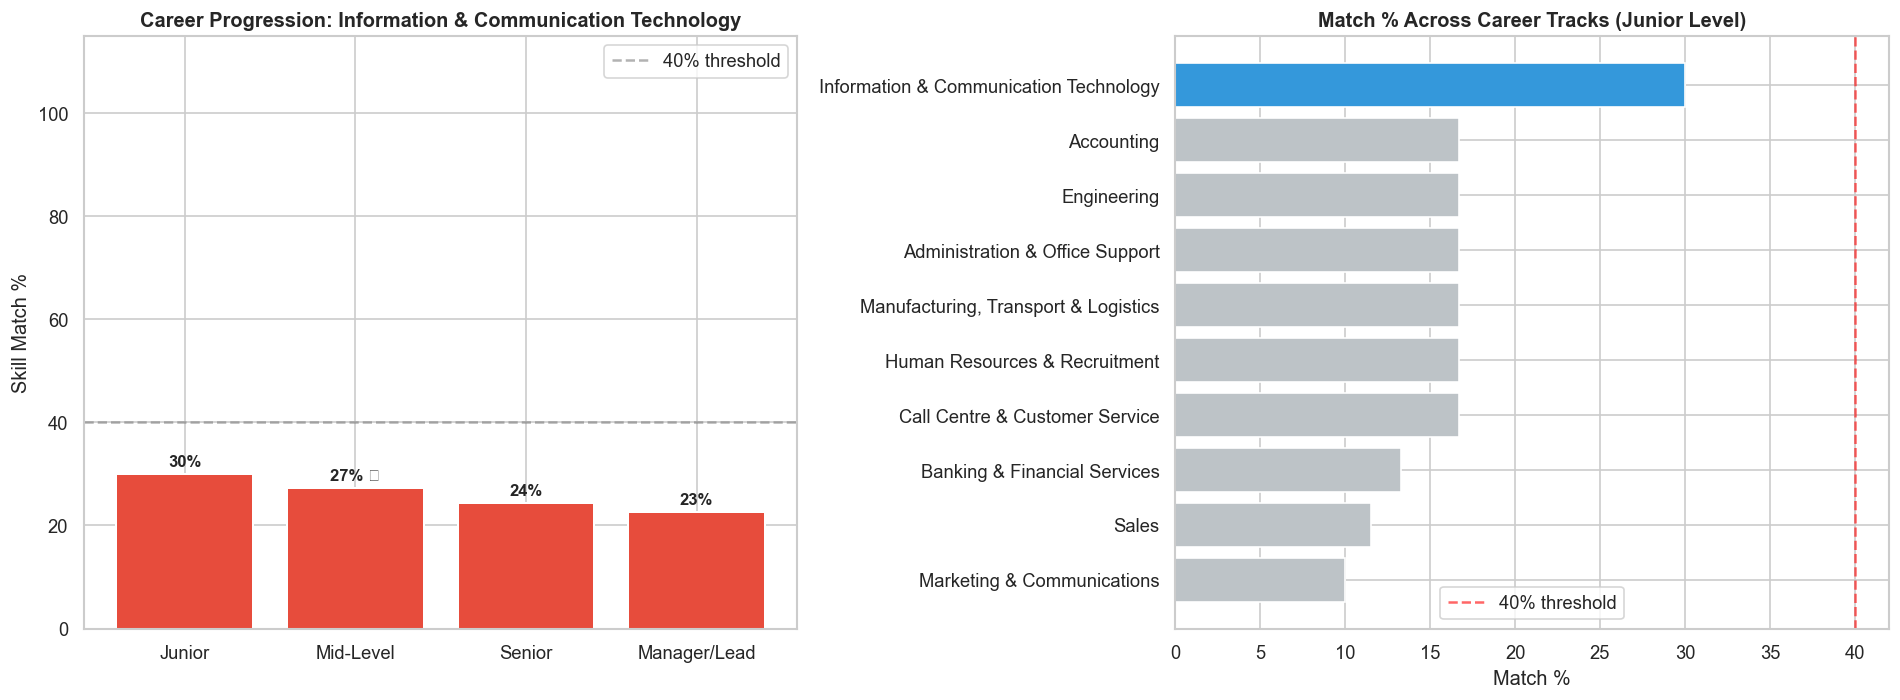

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tier progression for best track
tier_names = [t for t in TIER_ORDER if t in best_tiers]
tier_pcts  = [best_tiers[t]['match_pct'] for t in tier_names]
colors     = ['#2ecc71' if p >= 60 else '#e67e22' if p >= 40 else '#e74c3c' for p in tier_pcts]
axes[0].bar(tier_names, tier_pcts, color=colors, edgecolor='white', linewidth=1.2)
for i, (t, p) in enumerate(zip(tier_names, tier_pcts)):
    label = f'{p:.0f}%' + (' ★' if t == best_tier else '')
    axes[0].text(i, p + 1.5, label, ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(40, color='gray', linestyle='--', alpha=0.6, label='40% threshold')
axes[0].set_title(f'Career Progression: {best_track}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Skill Match %')
axes[0].set_ylim(0, 115)
axes[0].legend()

# All career tracks comparison
top10      = summary_df.head(10)
bar_colors = ['#3498db' if t == best_track else '#bdc3c7' for t in top10['Career Track']]
axes[1].barh(top10['Career Track'], top10['Junior %'], color=bar_colors)
axes[1].axvline(40, color='red', linestyle='--', alpha=0.6, label='40% threshold')
axes[1].set_title('Match % Across Career Tracks (Junior Level)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Match %')
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 9: Career Roadmap

In [24]:
print(f'CAREER ROADMAP: {best_track}')
print('=' * 60)

for tier in TIER_ORDER:
    if tier not in best_tiers:
        continue
    data = best_tiers[tier]
    if tier == best_tier:
        status = '★ You Are Here'
    elif data['match_pct'] >= 40:
        status = '✓ Achieved'
    else:
        status = '○ Next Goal'

    print(f'\n[{tier}]  {status}  ({data["match_pct"]:.0f}% match)')
    if data['matched']:
        print(f'  Have : {", ".join(data["matched"][:8])}')
    if data['missing']:
        print(f'  Need : {", ".join(data["missing"][:8])}')
        # Link to Objective 4 course recommendations
        for skill in data['missing'][:3]:
            match = job_recs_df[
                job_recs_df['missing_skill'].str.lower() == skill.lower()
            ].head(1)
            if not match.empty:
                c = match.iloc[0]
                print(f'  Course: [{skill}] {c["course_name"]} ({c.get("organization","N/A")})')

CAREER ROADMAP: Information & Communication Technology

[Junior]  ○ Next Goal  (30% match)
  Have : c, css, excel, html, java, javascript, mysql, python
  Need : accounting, agile, angular, aws, azure, communication, customer service, data analysis
  Course: [agile] Agile with Atlassian Jira (Atlassian)

[Mid-Level]  ★ You Are Here  (27% match)
  Have : c, css, excel, html, java, javascript, mysql, python
  Need : .net, accounting, agile, angular, aws, azure, communication, customer service
  Course: [agile] Agile with Atlassian Jira (Atlassian)

[Senior]  ○ Next Goal  (24% match)
  Have : c, css, excel, html, java, javascript, mysql, python
  Need : .net, accounting, agile, angular, aws, azure, ci/cd, communication
  Course: [agile] Agile with Atlassian Jira (Atlassian)

[Manager/Lead]  ○ Next Goal  (23% match)
  Have : c, css, excel, html, java, javascript, mysql, python
  Need : .net, accounting, agile, angular, aws, azure, ci/cd, communication
  Course: [agile] Agile with Atlassian

## Step 10: Alternative Career Paths

In [26]:
alt_tracks = summary_df[
    (summary_df['Career Track'] != best_track) &
    (summary_df['Junior %'] >= 30)
]['Career Track'].tolist()

print(f'Primary path : {best_track} ({best_pct:.1f}% match)')
print(f'\nAlternative paths ({len(alt_tracks)} viable):')

if alt_tracks:
    for track in alt_tracks[:5]:
        pct  = summary_df[summary_df['Career Track'] == track]['Junior %'].values[0]
        tier = track_results[track]['current_tier']
        need = track_results[track]['tiers'].get('Junior', {}).get('missing', [])[:5]
        print(f'\n  {track} ({pct:.1f}% match, {tier} level)')
        if need:
            print(f'    Skills to add: {", ".join(need)}')
else:
    print('  No other tracks reached 30% match threshold.')
    print('  Focus on building more skills for your primary track.')

Primary path : Information & Communication Technology (30.0% match)

Alternative paths (0 viable):
  No other tracks reached 30% match threshold.
  Focus on building more skills for your primary track.


## Step 11: Save Outputs

In [28]:
os.makedirs('data', exist_ok=True)

summary_df.to_csv('data/career_track_summary.csv', index=False)
print('Saved: data/career_track_summary.csv')

roadmap = {
    'best_track':      best_track,
    'best_match_pct':  best_pct,
    'current_tier':    best_tier,
    'next_tier':       next_tier,
    'years_experience':years_exp,
    'resume_skills':   resume_skills,
    'education':       resume_education,
    'tier_order':      TIER_ORDER,
    'alternative_tracks': [
        {'track': t,
         'match_pct': summary_df[summary_df['Career Track'] == t]['Junior %'].values[0],
         'tier': track_results[t]['current_tier']}
        for t in alt_tracks[:5]
    ],
    'all_tracks': summary_df.to_dict(orient='records'),
    'progression': {
        tier: {
            'match_pct': best_tiers[tier]['match_pct'],
            'matched':   best_tiers[tier]['matched'],
            'missing':   best_tiers[tier]['missing']
        }
        for tier in TIER_ORDER if tier in best_tiers
    }
}

with open('data/career_roadmap.json', 'w') as f:
    json.dump(roadmap, f, indent=2)
print('Saved: data/career_roadmap.json')

with open('data/dynamic_career_tracks.json', 'w') as f:
    json.dump(CAREER_TRACKS, f, indent=2)
print('Saved: data/dynamic_career_tracks.json')

Saved: data/career_track_summary.csv
Saved: data/career_roadmap.json
Saved: data/dynamic_career_tracks.json


## Step 12: Final Summary

In [30]:
print('=== CAREER PROFILE SUMMARY ===')
print(f'Skills Found : {len(resume_skills)}')
print(f'Experience   : {years_exp} years')
print(f'Education    : {resume_education[0] if resume_education else "N/A"}')
print(f'Best Track   : {best_track}')
print(f'Current Tier : {best_tier}')
print(f'Match %      : {best_pct:.1f}%')
print(f'Next Goal    : {next_tier if next_tier else "Already at top!"}')
print(f'Alt Paths    : {len(alt_tracks)} viable options')
print('=' * 30)

=== CAREER PROFILE SUMMARY ===
Skills Found : 10
Experience   : 4.3 years
Education    : Bachelor of Computer Science (Undergraduate) Aug 2023 - Aug 2026
Best Track   : Information & Communication Technology
Current Tier : Mid-Level
Match %      : 30.0%
Next Goal    : Senior
Alt Paths    : 0 viable options


In [31]:
# Save career tracks for Streamlit
import os
import re
import json
import pandas as pd

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

job_paths = [
    os.path.join(DATA_DIR, 'jobstreet_cleaned.csv'),
    os.path.join(DATA_DIR, 'jobstreet_all_job_dataset.csv'),
    'jobstreet_cleaned.csv',
    'jobstreet_all_job_dataset.csv'
]
job_path = next((p for p in job_paths if os.path.exists(p)), None)
if job_path is None:
    raise FileNotFoundError('JobStreet dataset not found.')

jobs_df = pd.read_csv(job_path)

def detect_col(df, names):
    for name in names:
        if name in df.columns:
            return name
    return None

TITLE_COL = detect_col(jobs_df, ['job_title', 'Job Title', 'title', 'position'])
DESC_COL = detect_col(jobs_df, ['job_description', 'descriptions', 'description', 'desc', 'requirements', 'job_text'])
CAT_COL = detect_col(jobs_df, ['category', 'Category', 'field', 'industry', 'job_category', 'specialization'])

if TITLE_COL is None or DESC_COL is None:
    raise ValueError('Required job columns not found.')

SKILL_KEYWORDS = [
    'python','java','javascript','typescript','c++','c#','c','r','php','ruby','html','css','react','angular','vue',
    'node.js','django','flask','fastapi','spring','express','.net','machine learning','deep learning','nlp',
    'data science','data analysis','statistics','feature engineering','etl','pandas','numpy','scikit-learn','tensorflow',
    'pytorch','sql','mysql','postgresql','mongodb','oracle','sqlite','aws','azure','gcp','docker','kubernetes',
    'jenkins','git','linux','airflow','kafka','spark','hadoop','databricks','snowflake','tableau','power bi','excel',
    'accounting','bookkeeping','auditing','taxation','financial reporting','financial analysis','budgeting','forecasting',
    'sap','quickbooks','xero','digital marketing','seo','sem','social media','content marketing','email marketing',
    'google ads','crm','salesforce','market research','recruitment','payroll','hris','performance management',
    'autocad','solidworks','electrical engineering','mechanical engineering','civil engineering','quality control',
    'patient care','clinical','nursing','pharmacy','laboratory','presentation','leadership','teamwork','negotiation',
    'customer service','problem solving','time management'
]
TIER_ORDER = ['Junior', 'Mid-Level', 'Senior', 'Manager/Lead']
SENIORITY_MAP = {
    'Junior': ['junior','entry','graduate','trainee','intern','fresh','associate','assistant'],
    'Mid-Level': ['mid','intermediate','experienced','specialist','executive'],
    'Senior': ['senior','sr.','lead','principal','expert','advanced'],
    'Manager/Lead': ['manager','head','director','chief','vp','vice president']
}

def get_tier(title):
    title = str(title).lower()
    for tier in reversed(TIER_ORDER):
        if any(word in title for word in SENIORITY_MAP[tier]):
            return tier
    return 'Mid-Level'

jobs_df[TITLE_COL] = jobs_df[TITLE_COL].fillna('').astype(str)
jobs_df[DESC_COL] = jobs_df[DESC_COL].fillna('').astype(str)
jobs_df['tier'] = jobs_df[TITLE_COL].apply(get_tier)

if CAT_COL and CAT_COL in jobs_df.columns:
    jobs_df[CAT_COL] = jobs_df[CAT_COL].fillna('Other').astype(str)
    valid_cats = jobs_df[CAT_COL].value_counts().head(20).index.tolist()
else:
    CAT_COL = 'career_track'
    jobs_df[CAT_COL] = 'All Roles'
    valid_cats = ['All Roles']

tracks = {}
summary_rows = []
for cat in valid_cats:
    cat_jobs = jobs_df[jobs_df[CAT_COL] == cat]
    tier_skills = {}
    for tier in TIER_ORDER:
        tier_jobs = cat_jobs[cat_jobs['tier'] == tier]
        combined = ' '.join(tier_jobs[DESC_COL].fillna('').astype(str).str.lower().tolist())
        found = {}
        for skill in SKILL_KEYWORDS:
            count = len(re.findall(r'\b' + re.escape(skill) + r'\b', combined))
            if count >= 2:
                found[skill] = count
        tier_skills[tier] = [s for s, _ in sorted(found.items(), key=lambda x: -x[1])[:25]]
    tracks[cat] = tier_skills
    summary_rows.append({'Career Track': cat, 'Job Count': len(cat_jobs)})

with open(os.path.join(DATA_DIR, 'dynamic_career_tracks.json'), 'w') as f:
    json.dump(tracks, f, indent=2)

pd.DataFrame(summary_rows).to_csv(os.path.join(DATA_DIR, 'career_track_summary.csv'), index=False)

print('Saved career tracks.')
print('Tracks:', len(tracks))

Saved career tracks.
Tracks: 20
